In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
import optuna
from optuna.samplers import TPESampler

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pathlib import Path

if not torch.cuda.is_available():
    raise RuntimeError(" CUDA no está disponible. Este notebook requiere GPU NVIDIA.")

device = torch.device("cuda")
print(" GPU detectada:", torch.cuda.get_device_name(0))


 GPU detectada: NVIDIA GeForce RTX 5060 Laptop GPU


D:\anaconda3\envs\rn_proyect\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
DATASET_DIR = Path("dataset_split")

SAVE_DIR = Path("results/cnn")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = SAVE_DIR / "cnn_pure.pth"
HISTORY_PATH = SAVE_DIR / "history_cnn_pure.pt"

FIGURES_DIR = SAVE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 384
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 100
LEARNING_RATE = 3e-4
PATIENCE = 15

In [22]:
# Variables de control

best_val_acc = 0.0
patience_counter = 0

In [23]:
# TRANSFORMS

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# DATASETS

train_ds = datasets.ImageFolder(DATASET_DIR / "train", transform=transform_train)
val_ds   = datasets.ImageFolder(DATASET_DIR / "val",   transform=transform_eval)
test_ds  = datasets.ImageFolder(DATASET_DIR / "test",  transform=transform_eval)


# DATALOADERS

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Clases:", train_ds.classes)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Clases: ['Aedes aegypti', 'Culex quinquefasciatus']
Train: 560 | Val: 120 | Test: 120


In [24]:
from models.cnn import CNNPure


model = CNNPure(num_classes=2).to(device)

if MODEL_PATH.exists():
    print(" Modelo entrenado encontrado. Cargando pesos...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
else:
    print(" No se encontró modelo previo. Se entrenará desde cero.")

 No se encontró modelo previo. Se entrenará desde cero.


In [25]:
def pytorch_summary(model, input_size=(3, 384, 384)):
    hooks = []
    summary = []

    def hook(module, input, output):
        if isinstance(module, (nn.Sequential, nn.ModuleList)) or module == model:
            return

        params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        out_shape = tuple(output.shape)
        summary.append((module.__class__.__name__, out_shape, params))

    for m in model.modules():
        hooks.append(m.register_forward_hook(hook))

    with torch.no_grad():
        model(torch.randn(1, *input_size).to(device))

    for h in hooks:
        h.remove()

    print("------------------------------------------------------------")
    print(f"{'Layer':<20} {'Output Shape':<25} {'Params'}")
    print("============================================================")
    for layer, shape, params in summary:
        print(f"{layer:<20} {str(shape):<25} {params}")
    print("============================================================")
    total = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total}")
    print("------------------------------------------------------------")

pytorch_summary(model)


------------------------------------------------------------
Layer                Output Shape              Params
Conv2d               (1, 32, 384, 384)         896
BatchNorm2d          (1, 32, 384, 384)         64
ReLU                 (1, 32, 384, 384)         0
MaxPool2d            (1, 32, 192, 192)         0
Conv2d               (1, 64, 192, 192)         18496
BatchNorm2d          (1, 64, 192, 192)         128
ReLU                 (1, 64, 192, 192)         0
MaxPool2d            (1, 64, 96, 96)           0
Conv2d               (1, 128, 96, 96)          73856
BatchNorm2d          (1, 128, 96, 96)          256
ReLU                 (1, 128, 96, 96)          0
MaxPool2d            (1, 128, 48, 48)          0
Conv2d               (1, 256, 48, 48)          295168
BatchNorm2d          (1, 256, 48, 48)          512
ReLU                 (1, 256, 48, 48)          0
AdaptiveAvgPool2d    (1, 256, 1, 1)            0
CNNFeatureExtractor  (1, 256)                  389376
Dropout              (1, 

In [26]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

In [27]:
def train_one_epoch(model, dataloader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in dataloader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def validate(model, dataloader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


### Uso de Optuna para búsqueda de hiperparámetros óptimos

In [28]:
def objective(trial):

    # -------- Hiperparámetros a optimizar --------
    lr = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.15)

    # -------- Dataloaders (batch variable) --------
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # -------- Modelo --------
    model = CNNPure(num_classes=2).to(device)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=label_smoothing
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_acc = 0.0
    patience_counter = 0

    EPOCHS_OPT = 40
    PATIENCE_OPT = 8

    # -------- Loop corto --------
    for epoch in range(EPOCHS_OPT):
        train_one_epoch(model, train_loader)
        _, val_acc = validate(model, val_loader)

        trial.report(val_acc, epoch)

        # Pruning automático
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE_OPT:
            break

    return best_val_acc

In [29]:
## EJECUCIÓN DE OPTUNA

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)

study.optimize(objective, n_trials=30)

print("\n================= OPTUNA RESULTS =================")
print("Best Validation Accuracy:", study.best_value)
print("Best Hyperparameters:")

for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")
print("==================================================")


[I 2025-12-29 23:27:55,686] A new study created in memory with name: no-name-bceab99f-e286-4d87-88c4-0e7e4d296ff0
[I 2025-12-29 23:29:26,006] Trial 0 finished with value: 0.6416666666666667 and parameters: {'learning_rate': 0.00043284502212938834, 'weight_decay': 0.0007114476009343421, 'batch_size': 16, 'label_smoothing': 0.023402796066365476}. Best is trial 0 with value: 0.6416666666666667.
[I 2025-12-29 23:31:21,749] Trial 1 finished with value: 0.5 and parameters: {'learning_rate': 0.00018408992080552527, 'weight_decay': 1.493656855461763e-06, 'batch_size': 16, 'label_smoothing': 0.10621088666940683}. Best is trial 0 with value: 0.6416666666666667.
[I 2025-12-29 23:34:00,795] Trial 2 finished with value: 0.5 and parameters: {'learning_rate': 0.00010838581269344756, 'weight_decay': 0.0008123245085588687, 'batch_size': 16, 'label_smoothing': 0.02727374508106509}. Best is trial 0 with value: 0.6416666666666667.
[I 2025-12-29 23:36:11,856] Trial 3 finished with value: 0.5 and parameters


================= OPTUNA RESULTS =================
Best Validation Accuracy: 0.7
Best Hyperparameters:
  learning_rate: 0.00415821257357592
  weight_decay: 8.921069671419496e-05
  batch_size: 16
  label_smoothing: 0.1074740148144811


In [30]:
# Entrenamiento FINAL

best_params = study.best_trial.params

BATCH_SIZE = best_params["batch_size"]
LEARNING_RATE = best_params["learning_rate"]

criterion = nn.CrossEntropyLoss(
    label_smoothing=best_params["label_smoothing"]
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=best_params["weight_decay"]
)

print("\nEntrenamiento FINAL con hiperparámetros:")
for k, v in best_params.items():
    print(f"  {k}: {v}")



Entrenamiento FINAL con hiperparámetros:
  learning_rate: 0.00415821257357592
  weight_decay: 8.921069671419496e-05
  batch_size: 16
  label_smoothing: 0.1074740148144811


In [31]:
### Reseteo de varaibles y dataloaders

best_val_acc = 0.0
patience_counter = 0

# DATALOADERS

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


In [32]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Guardar MEJOR modelo

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        improved = "look up!"
    else:
        patience_counter += 1
        improved = ""

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} {improved}"
    )

    # EARLY STOPPING

    if patience_counter >= PATIENCE:
        print(
            f"\n Early stopping activado en epoch {epoch+1}\n"
            f"   Mejor Val Acc: {best_val_acc:.4f}"
        )
        break

# Guardar historial

torch.save(history, HISTORY_PATH)

print(f"\nMejor modelo guardado en: {MODEL_PATH}")
print(f" Historial guardado en: {HISTORY_PATH}")


Epoch [001/100] | Train Acc: 0.7036 | Val Acc: 0.5083 look up!
Epoch [002/100] | Train Acc: 0.7375 | Val Acc: 0.7000 look up!
Epoch [003/100] | Train Acc: 0.7429 | Val Acc: 0.7167 look up!
Epoch [004/100] | Train Acc: 0.7768 | Val Acc: 0.6083 
Epoch [005/100] | Train Acc: 0.7750 | Val Acc: 0.5333 
Epoch [006/100] | Train Acc: 0.7643 | Val Acc: 0.5083 
Epoch [007/100] | Train Acc: 0.7589 | Val Acc: 0.5500 
Epoch [008/100] | Train Acc: 0.8089 | Val Acc: 0.7750 look up!
Epoch [009/100] | Train Acc: 0.8036 | Val Acc: 0.7167 
Epoch [010/100] | Train Acc: 0.7875 | Val Acc: 0.7833 look up!
Epoch [011/100] | Train Acc: 0.7661 | Val Acc: 0.6167 
Epoch [012/100] | Train Acc: 0.7571 | Val Acc: 0.7167 
Epoch [013/100] | Train Acc: 0.8161 | Val Acc: 0.6583 
Epoch [014/100] | Train Acc: 0.8107 | Val Acc: 0.7333 
Epoch [015/100] | Train Acc: 0.8196 | Val Acc: 0.7750 
Epoch [016/100] | Train Acc: 0.8179 | Val Acc: 0.8167 look up!
Epoch [017/100] | Train Acc: 0.8339 | Val Acc: 0.5833 
Epoch [018/100] |

In [33]:
if HISTORY_PATH.exists():
    print("Historial encontrado. Cargando...")
    history = torch.load(HISTORY_PATH)
else:
    raise RuntimeError(" No se encontró history.pt. El modelo debe entrenarse al menos una vez.")

Historial encontrado. Cargando...


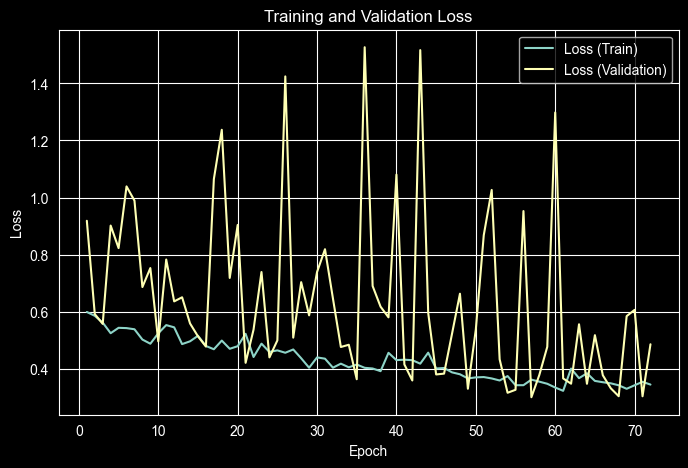

In [34]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Loss (Train)")
plt.plot(epochs, history["val_loss"], label="Loss (Validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(FIGURES_DIR / "loss_curve_cnn_pure.png", dpi=300, bbox_inches="tight")
plt.show()


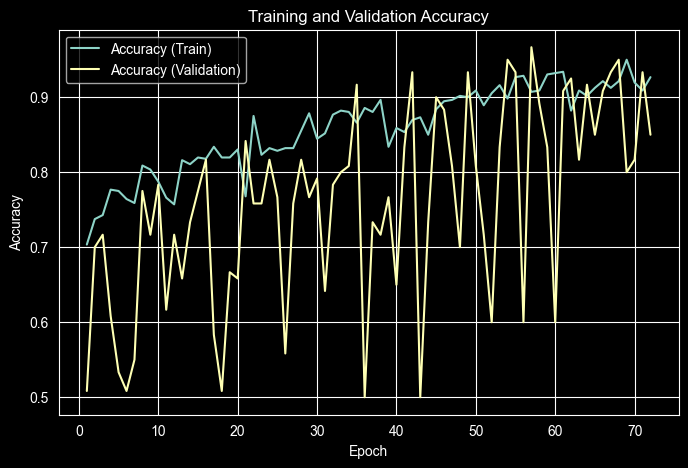

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Accuracy (Train)")
plt.plot(epochs, history["val_acc"], label="Accuracy (Validation)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(FIGURES_DIR / "accuracy_curve_cnn_pure.png", dpi=300, bbox_inches="tight")
plt.show()

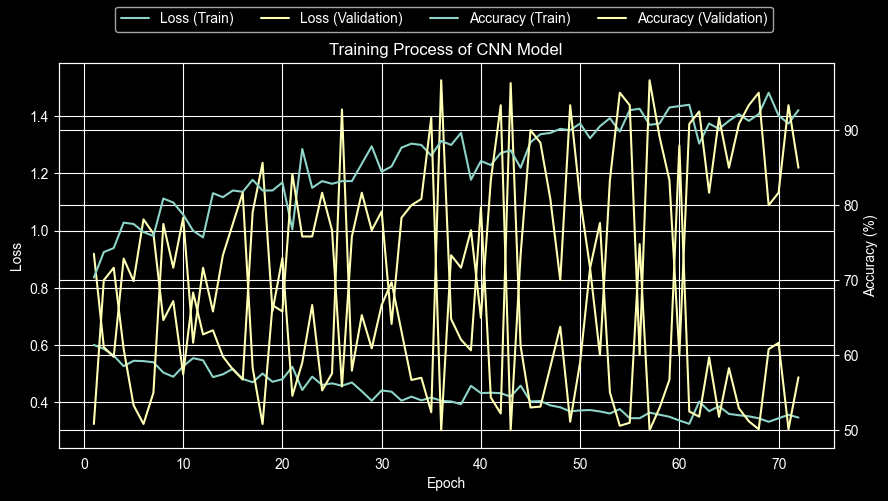

In [36]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.plot(epochs, history["train_loss"], label="Loss (Train)")
ax1.plot(epochs, history["val_loss"], label="Loss (Validation)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy (%)")
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], label="Accuracy (Train)")
ax2.plot(epochs, [a * 100 for a in history["val_acc"]], label="Accuracy (Validation)")

fig.legend(loc="upper center", ncol=4)
plt.title("Training Process of CNN Model")

plt.savefig(FIGURES_DIR / "training_process_cnn_pure.png", dpi=300, bbox_inches="tight")
plt.show()


### Métricas adicionales

In [37]:
model = CNNPure(num_classes=2).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

CNNPure(
  (features): CNNFeatureExtractor(
    (block1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block4): Sequential(
      (0): Conv2d

In [38]:
import numpy as np

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="binary")
rec = recall_score(y_true, y_pred, average="binary")
f1 = f1_score(y_true, y_pred, average="binary")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.9583
Precision: 0.9365
Recall   : 0.9833
F1-score : 0.9593


In [40]:
print(classification_report(
    y_true,
    y_pred,
    target_names=test_ds.classes
))


                        precision    recall  f1-score   support

         Aedes aegypti       0.98      0.93      0.96        60
Culex quinquefasciatus       0.94      0.98      0.96        60

              accuracy                           0.96       120
             macro avg       0.96      0.96      0.96       120
          weighted avg       0.96      0.96      0.96       120



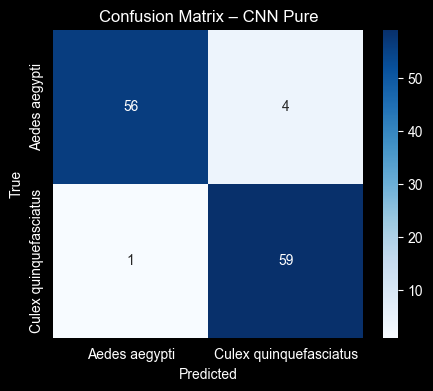

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_ds.classes,
    yticklabels=test_ds.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – CNN Pure")
plt.show()
